In [1]:
import os
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [7]:
import os

DATASET_PATH = r"C:\Data Science\NEU-DET"

print(os.listdir(DATASET_PATH))

['train', 'validation']


In [8]:
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "validation")

print("Train:", os.listdir(TRAIN_PATH))
print("Validation:", os.listdir(VAL_PATH))

Train: ['annotations', 'images']
Validation: ['annotations', 'images']


In [10]:
#Defing the four path

In [11]:
TRAIN_IMAGES = os.path.join(
    TRAIN_PATH,
    "images"
)

TRAIN_ANNOTATIONS = os.path.join(
    TRAIN_PATH,
    "annotations"
)

VAL_IMAGES = os.path.join(
    VAL_PATH,
    "images"
)

VAL_ANNOTATIONS = os.path.join(
    VAL_PATH,
    "annotations"
)

In [12]:
print("Training images:",
      os.path.exists(TRAIN_IMAGES))

print("Training annotations:",
      os.path.exists(TRAIN_ANNOTATIONS))

print("Validation images:",
      os.path.exists(VAL_IMAGES))

print("Validation annotations:",
      os.path.exists(VAL_ANNOTATIONS))

Training images: True
Training annotations: True
Validation images: True
Validation annotations: True


In [13]:
train_images = os.listdir(TRAIN_IMAGES)
train_annotations = os.listdir(TRAIN_ANNOTATIONS)

val_images = os.listdir(VAL_IMAGES)
val_annotations = os.listdir(VAL_ANNOTATIONS)

print("Training images:", len(train_images))
print("Training annotations:", len(train_annotations))

print("Validation images:", len(val_images))
print("Validation annotations:", len(val_annotations))

Training images: 6
Training annotations: 1439
Validation images: 6
Validation annotations: 361


In [14]:
import os

print("Training images folder:")
print(os.listdir(TRAIN_IMAGES))

print("\nValidation images folder:")
print(os.listdir(VAL_IMAGES))

Training images folder:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Validation images folder:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [15]:
#Counting the actual images

In [16]:
import os

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

print("TRAINING DATA")
print("-" * 40)

for class_name in classes:
    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print(f"{class_name}: {image_count}")

TRAINING DATA
----------------------------------------
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240


In [17]:
#Counting the validation images

In [18]:
print("VALIDATION DATA")
print("-" * 40)

for class_name in classes:
    class_path = os.path.join(
        VAL_IMAGES,
        class_name
    )

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    print(f"{class_name}: {image_count}")

VALIDATION DATA
----------------------------------------
crazing: 60
inclusion: 60
patches: 60
pitted_surface: 60
rolled-in_scale: 60
scratches: 60


In [19]:
#Creating sumary table

In [20]:
train_counts = {}

for class_name in classes:
    
    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )

    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    train_counts[class_name] = count


val_counts = {}

for class_name in classes:
    
    class_path = os.path.join(
        VAL_IMAGES,
        class_name
    )

    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    val_counts[class_name] = count


summary_df = pd.DataFrame({
    "Class": classes,
    "Training": [
        train_counts[c] for c in classes
    ],
    "Validation": [
        val_counts[c] for c in classes
    ]
})

summary_df

,Class,Training,Validation
0,crazing,240,60
1,inclusion,240,60
2,patches,240,60
3,pitted_surface,240,60
4,rolled-in_scale,240,60
5,scratches,240,60


In [21]:
#Plot class distribution

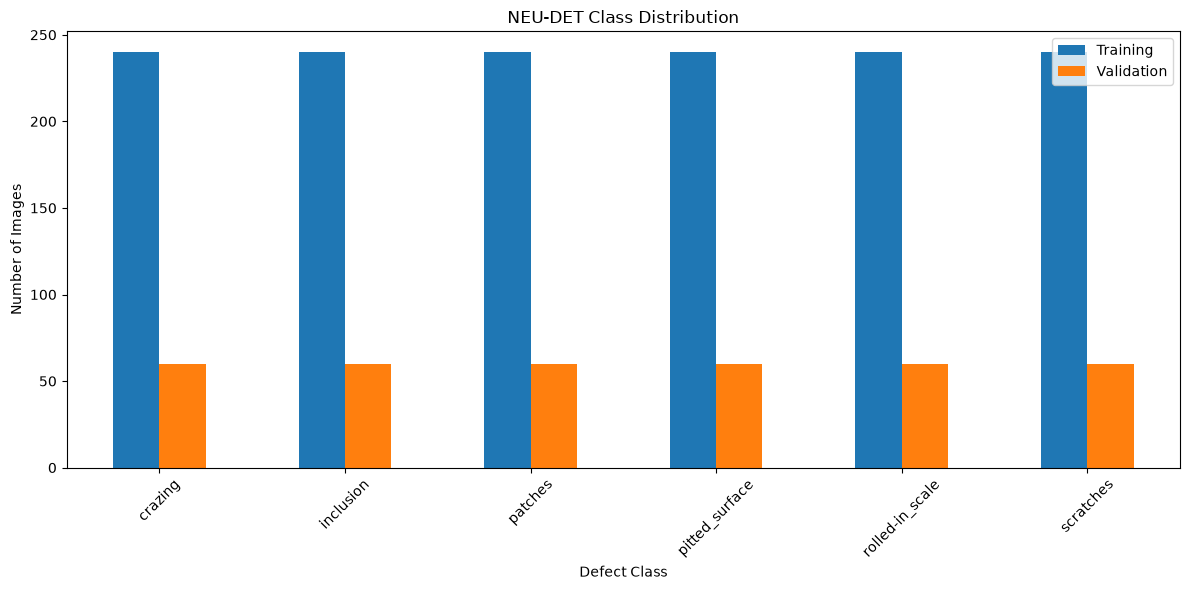

In [22]:
summary_df.set_index("Class")[["Training", "Validation"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("NEU-DET Class Distribution")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
#Display sample images

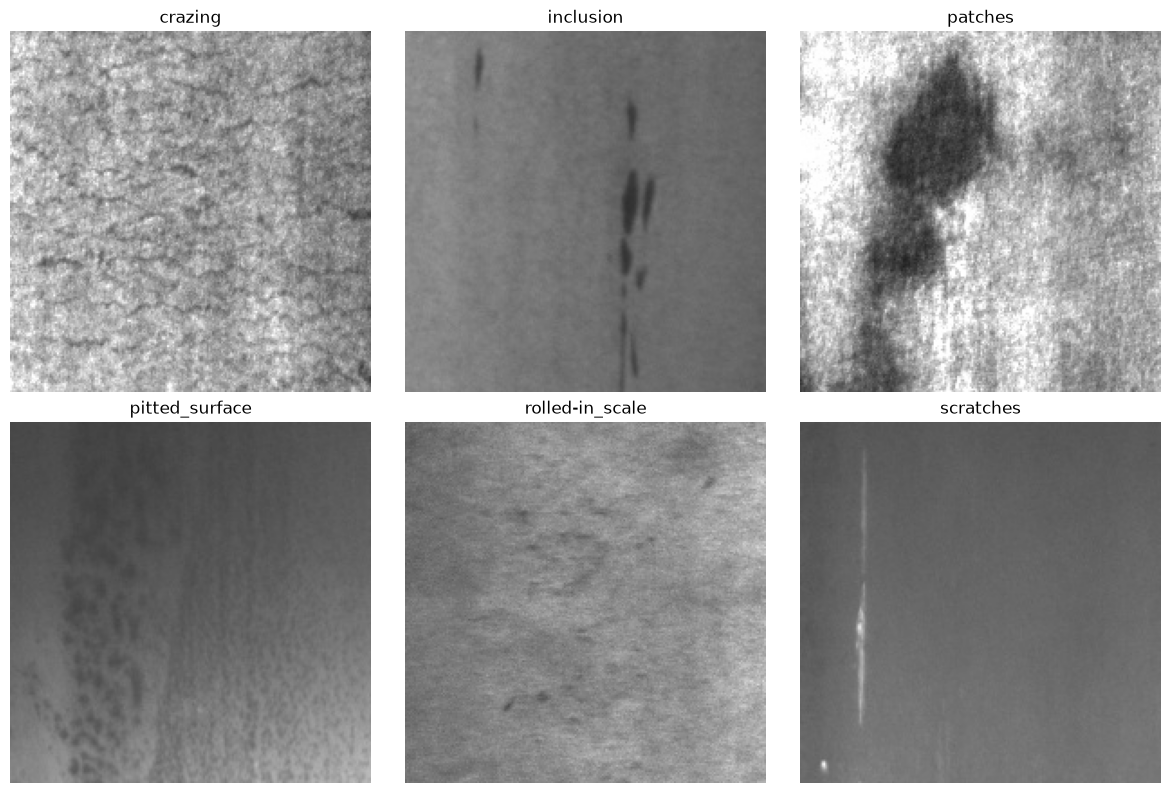

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for ax, class_name in zip(axes.flat, classes):

    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
#Checking size of theimages(original image dimesion)

In [26]:
for class_name in classes:

    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    print(
        f"{class_name}: {image.size}"
    )

crazing: (200, 200)
inclusion: (200, 200)
patches: (200, 200)
pitted_surface: (200, 200)
rolled-in_scale: (200, 200)
scratches: (200, 200)


In [27]:
for class_name in classes:

    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = Image.open(image_path)

    print(
        f"{class_name}: mode={image.mode}"
    )

crazing: mode=RGB
inclusion: mode=RGB
patches: mode=RGB
pitted_surface: mode=RGB
rolled-in_scale: mode=RGB
scratches: mode=RGB


In [ ]:
# Verify the dataset programmatically

In [29]:
data = []

for class_name in classes:
    
    class_path = os.path.join(
        TRAIN_IMAGES,
        class_name
    )
    
    for image_file in os.listdir(class_path):
        
        if image_file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            
            image_path = os.path.join(
                class_path,
                image_file
            )
            
            data.append({
                "image_path": image_path,
                "class": class_name
            })

train_df = pd.DataFrame(data)

print("Total training images:", len(train_df))
train_df.head()

Total training images: 1440


,image_path,class
0,C:\Data Science\NEU-DET\train\images\crazing\c...,crazing
1,C:\Data Science\NEU-DET\train\images\crazing\c...,crazing
2,C:\Data Science\NEU-DET\train\images\crazing\c...,crazing
3,C:\Data Science\NEU-DET\train\images\crazing\c...,crazing
4,C:\Data Science\NEU-DET\train\images\crazing\c...,crazing


In [30]:
#For validation

In [31]:
val_data = []

for class_name in classes:
    
    class_path = os.path.join(
        VAL_IMAGES,
        class_name
    )
    
    for image_file in os.listdir(class_path):
        
        if image_file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            
            image_path = os.path.join(
                class_path,
                image_file
            )
            
            val_data.append({
                "image_path": image_path,
                "class": class_name
            })

val_df = pd.DataFrame(val_data)

print("Total validation images:", len(val_df))
val_df.head()

Total validation images: 360


,image_path,class
0,C:\Data Science\NEU-DET\validation\images\craz...,crazing
1,C:\Data Science\NEU-DET\validation\images\craz...,crazing
2,C:\Data Science\NEU-DET\validation\images\craz...,crazing
3,C:\Data Science\NEU-DET\validation\images\craz...,crazing
4,C:\Data Science\NEU-DET\validation\images\craz...,crazing


In [ ]:
#Final check for blanced dataset

In [33]:
print("Training:")
print(train_df["class"].value_counts())

print("\nValidation:")
print(val_df["class"].value_counts())

Training:
class
crazing            240
inclusion          240
patches            240
pitted_surface     240
rolled-in_scale    240
scratches          240
Name: count, dtype: int64

Validation:
class
crazing            60
inclusion          60
patches            60
pitted_surface     60
rolled-in_scale    60
scratches          60
Name: count, dtype: int64


In [34]:
#Saving EDA Dataset tables:

In [36]:
os.makedirs("../reports", exist_ok=True)

In [37]:
train_df.to_csv(
    "../reports/train_metadata.csv",
    index=False
)

val_df.to_csv(
    "../reports/validation_metadata.csv",
    index=False
)